# TUGAS AKHIR

* Nama: Joice Ocrisa 
* NRP: 5003221066

## Harga Saham BBCA

In [23]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.tuning_lstm import train_lstm_tuning
from models import LSTMModel, FEDformer_Model
from utils.data_loader import load_stock_data, prepare_univariate_data
from utils.evaluation import calculate_metrics, plot_predictions, plot_comparison, print_metrics


In [24]:
# Configuration 
BANK_CODE = 'BBCA'  
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


### Data

In [25]:
# date 
start_date = '2004-06-30'
end_date = '2025-06-30'

# get data
df = load_stock_data(BANK_CODE)
df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]
print(f"\nUkuran data: {df.shape}")
print("Tanggal awal:", start_date)
print("Tanggal akhir:", end_date)
print("\nBerikut adalah 5 baris pertama data:")
df.head()

c:\Users\User\Documents\AA - TA\tugas-akhir\indonesia-bank-stock-dataset\datasets\BBCA\BBCA.csv

Ukuran data: (5179, 8)
Tanggal awal: 2004-06-30
Tanggal akhir: 2025-06-30

Berikut adalah 5 baris pertama data:


,Close,Date,High,Kode,Low,Nama,Open,Volume
16,187.5,2004-06-30,187.5,BBCA,182.5,Bank Central Asia Tbk.,185.0,291260000.0
17,177.5,2004-07-01,180.0,BBCA,175.0,Bank Central Asia Tbk.,180.0,203090000.0
18,180.0,2004-07-02,180.0,BBCA,177.5,Bank Central Asia Tbk.,177.5,490800000.0
19,180.0,2004-07-05,180.0,BBCA,180.0,Bank Central Asia Tbk.,180.0,0.0
20,187.5,2004-07-06,187.5,BBCA,180.0,Bank Central Asia Tbk.,182.5,826610000.0


In [4]:
# Missing Value 

missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")
df = df.dropna(subset=['Close'])


Missing values:
Close     0
Date      0
High      0
Kode      0
Low       0
Nama      0
Open      0
Volume    0
dtype: int64


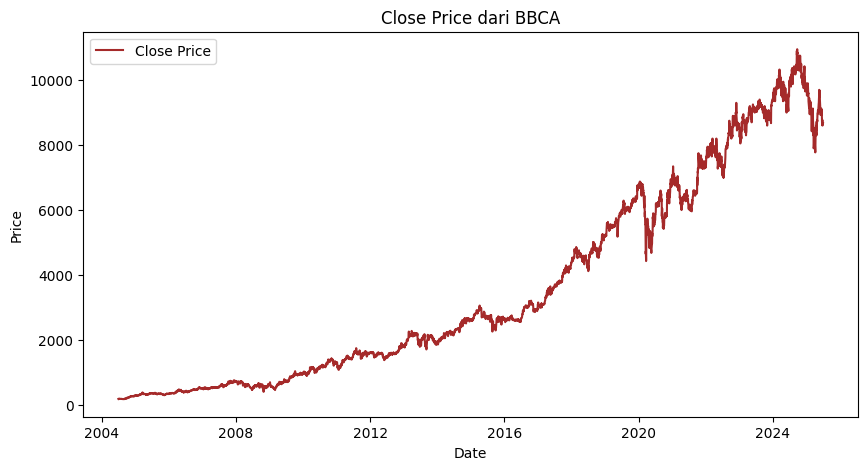

In [5]:
# Time Series Plot

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'brown')
plt.title('Close Price dari ' + BANK_CODE)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [26]:
# Split Data 

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_univariate_data(df, feature_col='Close', seq_len=SEQ_LEN)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3604, 30, 1), y_train shape: (3604, 1)
X_val shape: (772, 30, 1), y_val shape: (772, 1)
X_test shape: (773, 30, 1), y_test shape: (773, 1)


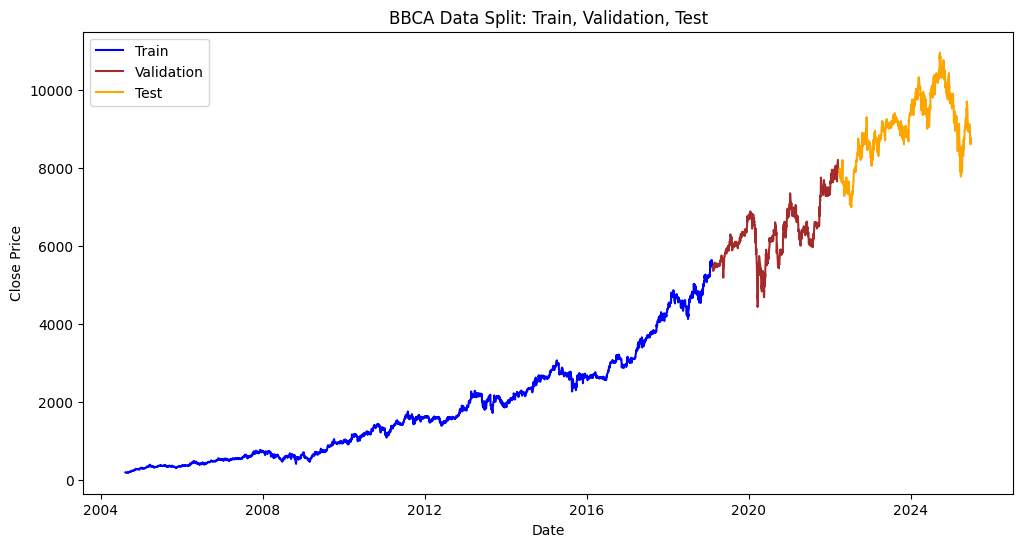

In [27]:
# Plot after split data
Train_size = len(X_train)
Val_size = len(X_val)
Test_size = len(X_test)

Date = df['Date'].values

# Define date for train val and test
idx_train_start = SEQ_LEN - 1
idx_train_end = idx_train_start + Train_size
idx_val_start = idx_train_end 
idx_val_end = idx_val_start + Val_size
idx_test_start = idx_val_end
idx_test_end = idx_test_start + Test_size

train_dates = Date[idx_train_start:idx_train_end]
val_dates = Date[idx_val_start:idx_val_end]
test_dates = Date[idx_test_start:idx_test_end]

# Ensure dates and target lengths match
target_train = y_train[:,0] if y_train.ndim > 1 else y_train
target_val = y_val[:,0] if y_val.ndim > 1 else y_val
target_test = y_test[:,0] if y_test.ndim > 1 else y_test

# Ensure target 1D for plotting
train_inv = scaler.inverse_transform(target_train.reshape(-1, 1)).flatten()
val_inv = scaler.inverse_transform(target_val.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(target_test.reshape(-1, 1)).flatten()

# To avoid if there is a mismatch shape
train_n = min(len(train_dates), len(train_inv))
val_n = min(len(val_dates), len(val_inv))
test_n = min(len(test_dates), len(test_inv))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_dates[:train_n], train_inv[:train_n], label='Train', color='blue')
plt.plot(val_dates[:val_n], val_inv[:val_n], label='Validation', color='brown')
plt.plot(test_dates[:test_n], test_inv[:test_n], label='Test', color='orange')

plt.title(BANK_CODE + ' Data Split: Train, Validation, Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [28]:
# Buat data yang sesuai dengan Data Loader
class stockdataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = stockdataset(X_train, y_train)
val_dataset = stockdataset(X_val, y_val)    
test_dataset = stockdataset(X_test, y_test)

# Gunakan DataLoader untuk batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)    

## **LSTM Model**

### Train-Validation LSTM 

In [29]:
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# LSTMModel 
from models import LSTMModel
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=0.2
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# menurunkan learning rate secara bertahap selama training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # X_batch = X_batch.to(DEVICE)
        # y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print("LSTM Training Complete!")

Epoch [1/100], Train Loss: 0.0084, Val Loss: 0.0006
Epoch [10/100], Train Loss: 0.0001, Val Loss: 0.0008
Epoch [20/100], Train Loss: 0.0001, Val Loss: 0.0007
Epoch [30/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [40/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [50/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [60/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [70/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [80/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [90/100], Train Loss: 0.0000, Val Loss: 0.0006
Epoch [100/100], Train Loss: 0.0000, Val Loss: 0.0006
LSTM Training Complete!


### Tuning Hyperparameter LSTM

In [10]:
# List Hyperparameter
dropout_list = [0.1, 0.2, 0.3]
lr_list = [1e-1, 1e-2, 1e-3]
batch_size_list = [32, 64, 128]

In [11]:
import itertools

results = []

for dropout, lr, batch_size in itertools.product(
        dropout_list, lr_list, batch_size_list):

    val_loss = train_lstm_tuning(dropout, lr, batch_size, train_dataset, val_dataset, DEVICE)
    results.append({
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch_size,
        'val_loss': val_loss
    })
    print(f"Dropout={dropout}, LR={lr}, Batch={batch_size}, Val Loss={val_loss:.6f}")

best_config = min(results, key=lambda x: x['val_loss'])

print("\n\nBest Hyperparameter Configuration:")
print(best_config)

Dropout=0.1, LR=0.1, Batch=32, Val Loss=0.005214
Dropout=0.1, LR=0.1, Batch=64, Val Loss=0.005677
Dropout=0.1, LR=0.1, Batch=128, Val Loss=0.014363
Dropout=0.1, LR=0.01, Batch=32, Val Loss=0.059248
Dropout=0.1, LR=0.01, Batch=64, Val Loss=0.128825
Dropout=0.1, LR=0.01, Batch=128, Val Loss=0.001708
Dropout=0.1, LR=0.001, Batch=32, Val Loss=0.000771
Dropout=0.1, LR=0.001, Batch=64, Val Loss=0.000295
Dropout=0.1, LR=0.001, Batch=128, Val Loss=0.000483
Dropout=0.2, LR=0.1, Batch=32, Val Loss=0.005840
Dropout=0.2, LR=0.1, Batch=64, Val Loss=0.008059
Dropout=0.2, LR=0.1, Batch=128, Val Loss=0.107075
Dropout=0.2, LR=0.01, Batch=32, Val Loss=0.000690
Dropout=0.2, LR=0.01, Batch=64, Val Loss=0.123423
Dropout=0.2, LR=0.01, Batch=128, Val Loss=0.168855
Dropout=0.2, LR=0.001, Batch=32, Val Loss=0.000326
Dropout=0.2, LR=0.001, Batch=64, Val Loss=0.000326
Dropout=0.2, LR=0.001, Batch=128, Val Loss=0.003511
Dropout=0.3, LR=0.1, Batch=32, Val Loss=0.007624
Dropout=0.3, LR=0.1, Batch=64, Val Loss=0.014

### Training Validation with Best Hyperparameter

In [ ]:
SEQ_LEN = 30  
PRED_LEN = 1  
EPOCHS = 100 
BATCH_SIZE = best_config['batch_size']
LEARNING_RATE = best_config['learning_rate']
dropout = best_config['dropout']

# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=dropout
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.006483 | Val Loss: 0.000579
Epoch [2/100] | Train Loss: 0.000148 | Val Loss: 0.001312
Epoch [3/100] | Train Loss: 0.000147 | Val Loss: 0.001288
Epoch [4/100] | Train Loss: 0.000114 | Val Loss: 0.001766
Epoch [5/100] | Train Loss: 0.000115 | Val Loss: 0.000639
Epoch [6/100] | Train Loss: 0.000107 | Val Loss: 0.000916
Epoch [7/100] | Train Loss: 0.000098 | Val Loss: 0.001801
Epoch [8/100] | Train Loss: 0.000076 | Val Loss: 0.001234
Epoch [9/100] | Train Loss: 0.000090 | Val Loss: 0.001932
Epoch [10/100] | Train Loss: 0.000075 | Val Loss: 0.001509
Epoch [11/100] | Train Loss: 0.000076 | Val Loss: 0.000682
Epoch [12/100] | Train Loss: 0.000070 | Val Loss: 0.000656
Epoch [13/100] | Train Loss: 0.000075 | Val Loss: 0.001169
Epoch [14/100] | Train Loss: 0.000066 | Val Loss: 0.000726
Epoch [15/100] | Train Loss: 0.000066 | Val Loss: 0.000872
Epoch [16/100] | Train Loss: 0.000064 | Val Loss: 0.000826
Epoch [17/100] | Train Loss: 0.000061 | Val Loss: 0.000776
Epoch 

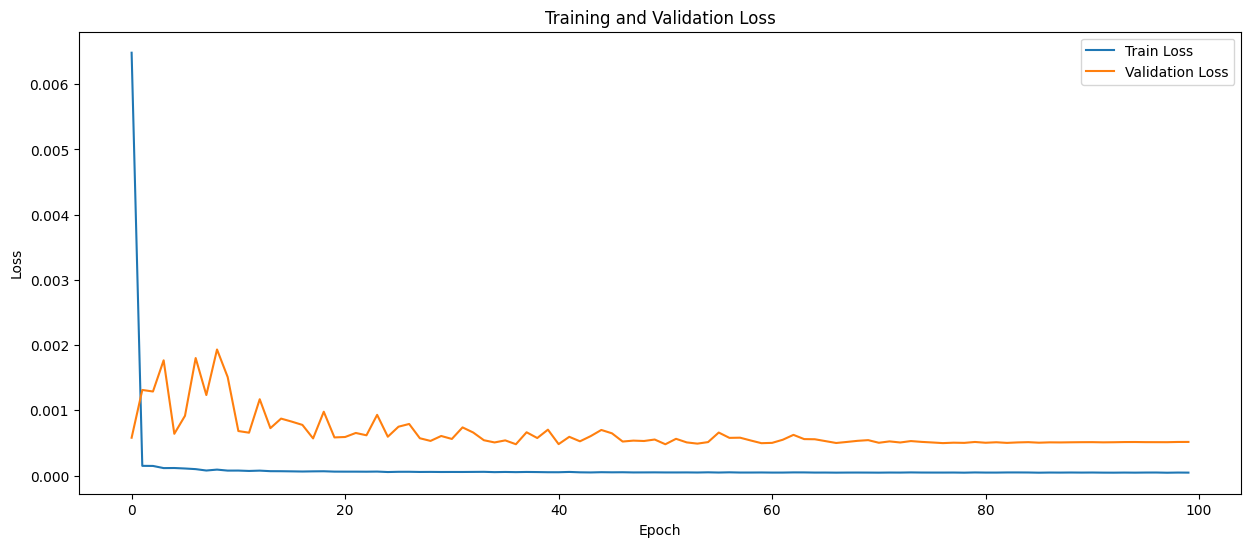

In [31]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [32]:
lstm_model.eval()

lstm_predictions = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        lstm_out = lstm_model(X_batch)
        lstm_out = lstm_out.cpu().numpy().flatten()

        lstm_predictions.append(lstm_out)
        y_true_list.append(y_batch.cpu().numpy().flatten())

lstm_pred = np.concatenate(lstm_predictions)
y_true = np.concatenate(y_true_list)

if scaler is not None:
    lstm_pred = scaler.inverse_transform(
        lstm_pred.reshape(-1, 1)
    ).flatten()

    y_true = scaler.inverse_transform(
        y_true.reshape(-1, 1)
    ).flatten()

In [34]:
# Calculate metrics
lstm_metrics = calculate_metrics(y_true, lstm_pred)

print_metrics(lstm_metrics, "LSTM")


LSTM Metrics:
----------------------------------------
MAE       : 610.1718
MSE       : 462202.7812
RMSE      : 679.8550
MAPE      : 6.5369%
R2        : 0.3359
----------------------------------------


## **FEDformer Model**

### Train-Validation FEDformer